In [6]:
import pandas as pd
df=pd.read_csv('spam.csv',encoding='latin-1')[['v1','v2']]
df.columns=['label','text']
df['label']=df['label'].map({'ham':0,'spam':1})
df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df['text_length']=df['text'].apply(len)
df['num_words']=df['text'].apply(lambda x: len(x.split()))
df['num_digits']=df['text'].apply(lambda x: sum(c.isdigit() for c in x))

In [8]:
x=df[['text_length','num_words','num_digits']]
y=df['label']
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.transform(x_test)


In [15]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
gnb=GaussianNB()
gnb.fit(x_train_scaled,y_train)
y_pred=gnb.predict(x_test_scaled)

accuracy:  0.9802690582959641


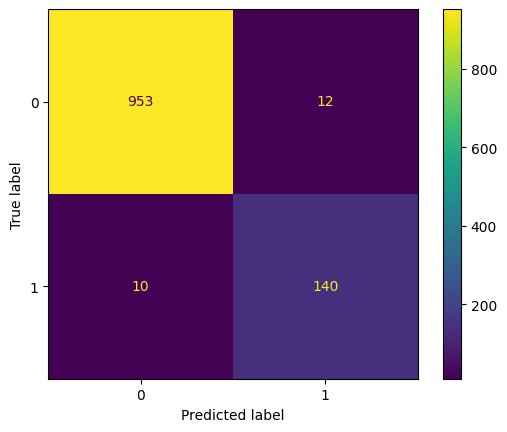

In [16]:
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay
print("accuracy: ",accuracy_score(y_test,y_pred))
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
# ConfusionMatrixDisplay.from_predictions(y_test,y_pred,features=['text_length','num_words','num_digits'],classes=['Not Spam','Spam'])
plt.show()

accuracy:  0.968609865470852


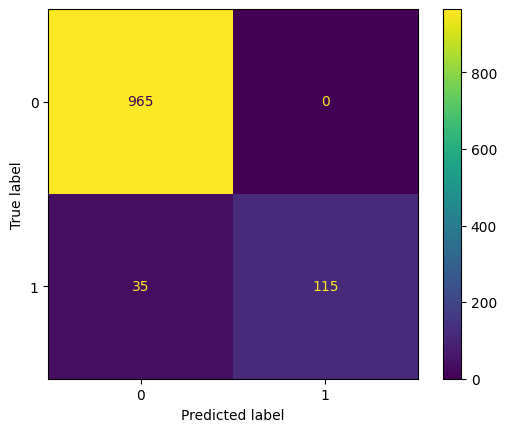

In [19]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfTransformer
vectorizer=CountVectorizer(stop_words='english')
x_counts=vectorizer.fit_transform(df['text'])
tfidfTransformer=TfidfTransformer()
x_tfidf=tfidfTransformer.fit_transform(x_counts)
x_train,x_test,y_train,y_test=train_test_split(x_tfidf,df['label'],test_size=0.2,random_state=42)
model=MultinomialNB()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("accuracy: ",accuracy_score(y_test,y_pred))
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
# ConfusionMatrixDisplay.from_predictions(y_test,y_pred,features=['text_length','num_words','num_digits'],classes=['Not Spam','Spam'])
plt.show()


In [23]:
from sklearn.metrics import confusion_matrix
important_words=["free","win","offer","money","urgent"]
for word in important_words:
    df[word]=df['text'].apply(lambda x:1 if word in x.lower() else 0)
x=df[important_words]
y=df['label']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model3=BernoulliNB()
model3.fit(x_train,y_train)
y_pred=model3.predict(x_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))

Accuracy: 0.895067264573991
Confusion Matrix:
 [[929  36]
 [ 81  69]]


In [29]:
df['label'].value_counts()

label
0    4825
1     747
Name: count, dtype: int64

In [ ]:
# Load the dataset and explore the message content and labels.
# Identify how many messages belong to each category.
# Build a probabilistic classification model that can learn patterns from word occurrences.
# Train the model using historical message data.
# Predict whether unseen messages are:
# Suspicious
# Not suspicious
# Test the system using custom user-entered messages.
# Evaluate the model using appropriate classification metrics.
# Analyze the following:
# How many suspicious messages were correctly identified?
# How many genuine messages were incorrectly flagged?

0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: label, Length: 5572, dtype: int64